# AC6 - ANOVA

## 1. Descripción del dataset

El dataset seleccionado es sobre ratings de chocolate, y tiene demás información como país de producción y porcentaje de cacao.


In [2]:
# download kaggle dataset
import os
from pathlib import Path
import os
import kagglehub
import pandas as pd
from functools import cache


# download the dataset from Kaggle using kagglehub
data_path = kagglehub.dataset_download("rtatman/chocolate-bar-ratings", output_dir="./data")
print("Dataset path:", Path().cwd() / data_path)
data_dir = Path(data_path)

csv_file = next(data_dir.rglob("*.csv"))
print("Found dataset file:", csv_file)

df = pd.read_csv(csv_file)

display(df)



C:\Users\XPC\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 30.3k/30.3k [00:00<00:00, 1.71MB/s]

Extracting files...
Dataset path: c:\Users\XPC\Documents\GitHub\Experimentos_TempName\AC6-ANOVA\data
Found dataset file: data\flavors_of_cacao.csv


,Company \n(Maker-if known),Specific Bean Origin\nor Bar Name,REF,Review\nDate,Cocoa\nPercent,Company\nLocation,Rating,Bean\nType,Broad Bean\nOrigin
0,A. Morin,Agua Grande,1876,2016,63%,France,3.75,,Sao Tome
1,A. Morin,Kpime,1676,2015,70%,France,2.75,,Togo
2,A. Morin,Atsane,1676,2015,70%,France,3.00,,Togo
3,A. Morin,Akata,1680,2015,70%,France,3.50,,Togo
4,A. Morin,Quilla,1704,2015,70%,France,3.50,,Peru
...,...,...,...,...,...,...,...,...,...
1790,Zotter,Peru,647,2011,70%,Austria,3.75,,Peru
1791,Zotter,Congo,749,2011,65%,Austria,3.00,Forastero,Congo
1792,Zotter,Kerala State,749,2011,65%,Austria,3.50,Forastero,India
1793,Zotter,Kerala State,781,2011,62%,Austria,3.25,,India


## 2. Hipótesis

Nos interesa estudiar la relación del rating con el porcentaje de cacao. Para eso, conviene dividir el dataset en 4 grupos: <70%, 70-74%, 75-79%, y ≥80%

### H0
La calificación promedio de las barras de chocolate es igual en los cuatro grupos de contenido de cacao.

$$
H_0: \mu_{<70\%}
= \mu_{70\text{–}<75\%}
= \mu_{75\text{–}<80\%}
= \mu_{\geq 80\%}
$$

### H1
Uno o más de los cuatro grupos de contenido de cacao presenta una calificación promedio diferente. Para esto hay varias hipótesis H1.

$$
H_1:
\mu_{<70\%} \neq \mu_{70\text{–}<75\%}
$$
$$
H_1:
\mu_{<70\%} \neq \mu_{75\text{–}<80\%}
$$
$$
H_1:
\mu_{<70\%} \neq \mu_{\geq 80\%}
$$
$$
H_1:
\mu_{70\text{–}<75\%} \neq \mu_{75\text{–}<80\%}
$$
$$
H_1:
\mu_{70\text{–}<75\%} \neq \mu_{\geq 80\%}
$$
$$
H_1:
\mu_{75\text{–}<80\%} \neq \mu_{\geq 80\%}
$$

In [3]:
# Dividir el dataset en los grupos de porcentaje.
datos = df.copy()

# Limpiar saltos de línea y espacios en los nombres de columnas.
datos.columns = (
    datos.columns.str.replace(r"\s+", " ", regex=True).str.strip()
)

# Convertir las variables a números.
datos["Cocoa Percent"] = pd.to_numeric(
    datos["Cocoa Percent"].astype(str).str.replace("%", "", regex=False),
    errors="coerce"
)
datos["Rating"] = pd.to_numeric(datos["Rating"], errors="coerce")

# Excluir registros sin porcentaje o calificación.
datos = datos.dropna(subset=["Cocoa Percent", "Rating"]).copy()

etiquetas = ["<70%", "70–<75%", "75–<80%", "≥80%"]

datos["Grupo_cacao"] = pd.cut(
    datos["Cocoa Percent"],
    bins=[float("-inf"), 70, 75, 80, float("inf")],
    labels=etiquetas,
    right=False
)

# Diccionario con las calificaciones de cada grupo.
grupos = {
    etiqueta: datos.loc[datos["Grupo_cacao"] == etiqueta, "Rating"]
    for etiqueta in etiquetas
}

display(
    datos.groupby("Grupo_cacao", observed=False)["Rating"]
    .agg(n="count", media="mean", desviacion="std")
)

,n,media,desviacion
Grupo_cacao,,,
<70%,328,3.188262,0.458315
70–<75%,988,3.245192,0.460210
75–<80%,296,3.155405,0.463869
≥80%,183,2.911202,0.530625



## 3. Comprobación de supuestos de ANOVA

### 3.1 Normalidad
Se puede notar que hay más ratings de chocolates entre el 70-75%, pero como todos tienen más de 50 observaciones, se usa lilliefors para ver la normalidad en cada grupo.

In [4]:
from statsmodels.stats.diagnostic import lilliefors

resultados = []

for nombre, calificaciones in grupos.items():
    estadistico, p = lilliefors(
        calificaciones,
        dist="norm",
        pvalmethod="table"
    )

    resultados.append({
        "Grupo": nombre,
        "n": len(calificaciones),
        "Estadístico": estadistico,
        "p_value": p,
        "Conclusión": (
            "Se rechaza la normalidad"
            if p < 0.05
            else "No se rechaza la normalidad"
        )
    })

display(pd.DataFrame(resultados))

,Grupo,n,Estadístico,p_value,Conclusión
0,<70%,328,0.139000,0.001,Se rechaza la normalidad
1,70–<75%,988,0.151396,0.001,Se rechaza la normalidad
2,75–<80%,296,0.122572,0.001,Se rechaza la normalidad
3,≥80%,183,0.172991,0.001,Se rechaza la normalidad


Según lilliefors, se rechaza la normalidad en los 4 grupos, pero se observa el Q-Q para ver si es por datos extremos.

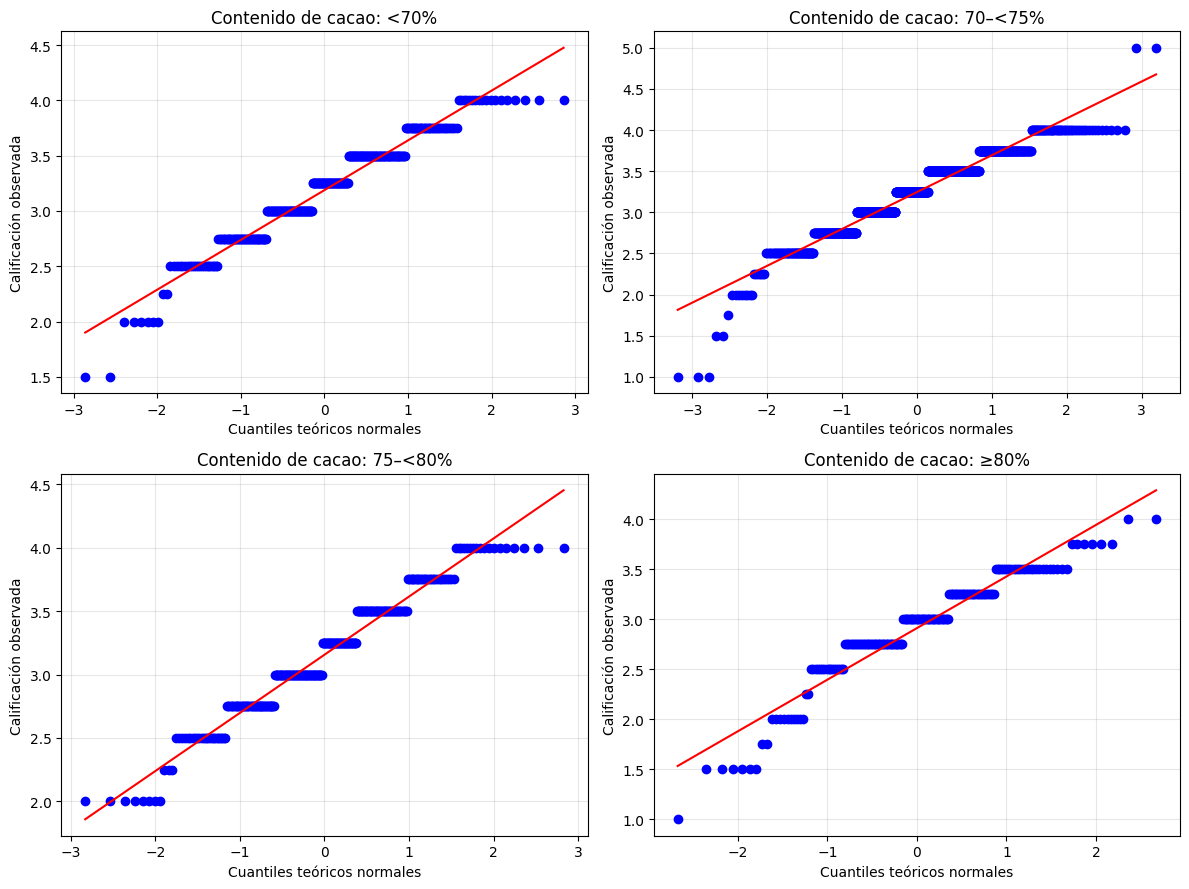

In [5]:
import matplotlib.pyplot as plt
from scipy.stats import probplot

fig, ejes = plt.subplots(2, 2, figsize=(12, 9))

for eje, (nombre, calificaciones) in zip(ejes.flat, grupos.items()):
    probplot(calificaciones.dropna(), dist="norm", plot=eje)

    eje.set_title(f"Contenido de cacao: {nombre}")
    eje.set_xlabel("Cuantiles teóricos normales")
    eje.set_ylabel("Calificación observada")
    eje.grid(alpha=0.3)

plt.tight_layout()
plt.show()

De los gráficos Q-Q no se puede determinar que es normal, sin embargo, se puede observar que los valores están escalonados por la naturaleza de las calificaciones. Una razón por la que las pruebas de lilliefors no dieron normales es por los valores escalonados y valores extremos en el caso de los grupos del <70% y 70-75%.

Según lo discutido en clases con la profesora, ANOVA no es tan sensible a la normalidad, por lo que se puede proseguir.

### 3.2 Homocedasticidad

Para la prueba de homocedasticidad, se usa Levene porque es más robusta a la no normalidad.

In [6]:
# homocedasticidad con Levene con grupos
from scipy.stats import levene

levene_test = levene(grupos["<70%"], grupos["70–<75%"], grupos["75–<80%"], grupos["≥80%"])
print(f"Levene test: statistic={levene_test.statistic:.4f}, p-value={levene_test.pvalue:.4f}")
if levene_test.pvalue < 0.05:
    print("Se rechaza la hipótesis nula de homocedasticidad. Los grupos no tienen varianzas iguales.")
else:
    print("No se rechaza la hipótesis nula de homocedasticidad. Los grupos tienen varianzas iguales.")


Levene test: statistic=0.7701, p-value=0.5107
No se rechaza la hipótesis nula de homocedasticidad. Los grupos tienen varianzas iguales.


### 3.3 Independencia

Cada observacion del dataset es independiente, ya que cada observacion corresponde a una barra de chocolate de un lote y la calificacion de la barra de chocolate corresponde a la experiencia obtenida con esa barra de chocolate. En la descripcion del dataset no se indica que la evulacion de una barra de chocolate influya en la evaluacion de otra, asi que se puede asumir que las observaciones son independientes.

## 4. ANOVA

### 4.1 Calcular ANOVA


In [7]:
# prueba de ANOVA
from scipy.stats import f_oneway
import statsmodels.api as sm
import statsmodels.formula.api as smf

# modelo one-way ANOVA 
model = smf.ols(
    "Rating ~ C(Q('Grupo_cacao'))",
    data=datos
).fit()

anova = sm.stats.anova_lm(model, typ=2)

anova

,sum_sq,df,F,PR(>F)
C(Q('Grupo_cacao')),17.559452,3.0,26.711811,6.709888e-17
Residual,392.447860,1791.0,NaN,NaN


## 5. Prueba post hoc: Tukey HSD

Como el ANOVA rechazó la hipótesis nula, se utiliza Tukey HSD para identificar qué pares de grupos de porcentaje de cacao presentan diferencias significativas en la calificación promedio, con un nivel de significancia de $\alpha = 0.05$. Esta prueba ajusta las comparaciones múltiples para controlar el error de tipo I.

In [8]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukeyResult = pairwise_tukeyhsd(
    endog=datos["Rating"],
    groups=datos["Grupo_cacao"],
    alpha=0.05
)

print(tukeyResult.summary())

 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
70–<75% 75–<80%  -0.0898 0.0201 -0.1695   -0.01   True
70–<75%    <70%  -0.0569 0.2248 -0.1336  0.0198  False
70–<75%    ≥80%   -0.334    0.0 -0.4309 -0.2371   True
75–<80%    <70%   0.0329 0.8176 -0.0636  0.1294  False
75–<80%    ≥80%  -0.2442    0.0 -0.3574  -0.131   True
   <70%    ≥80%  -0.2771    0.0 -0.3881  -0.166   True
------------------------------------------------------


### 5.2 Interpretación de Tukey HSD

Con un nivel de significancia de α = 0.05, la prueba post hoc de Tukey HSD identificó diferencias estadísticamente significativas en cuatro de las seis comparaciones realizadas. El grupo con un porcentaje de cacao ≥80% presentó una calificación promedio significativamente menor que los otros tres grupos. Además, se identificó una diferencia significativa entre los grupos de 70–<75% y 75–<80%, siendo mayor la calificación promedio del primero. Las comparaciones restantes no mostraron diferencias estadísticamente significativas (p ajustado ≥ 0.05).